# Math Glossary for Machine Learning

A reference for the core mathematical concepts used across all notebooks in this series.  
Each concept follows the same structure: **intuition → key formula → plot**.

---

## Table of Contents

1. [Linear Algebra](#1-linear-algebra)
   - Vectors & Matrices
   - Matrix Multiplication
   - Transpose & Inverse
   - Dot Product
   - Eigenvalues & Eigenvectors
2. [Calculus](#2-calculus)
   - Derivatives
   - Partial Derivatives
   - The Chain Rule
   - Gradients
3. [Probability & Statistics](#3-probability--statistics)
   - Random Variables, Expectation, Variance
   - Common Distributions
   - Covariance & Correlation
   - Bayes' Theorem
4. [Convexity & Norms](#4-convexity--norms)
   - Convexity
   - L1, L2 and other Norms

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm, bernoulli, binom, multivariate_normal
import os

os.makedirs('img', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'text.color':       '#eee',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.8,
    'font.family':      'monospace',
    'axes.titlesize':   12,
    'axes.labelsize':   11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'
YELLOW = '#ffd60a'

---
## 1. Linear Algebra

### 1.1 Vectors & Matrices

A **vector** $v \in \mathbb{R}^n$ is a list of $n$ numbers. Geometrically: an arrow in $n$-dimensional space.

$$v = \begin{pmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{pmatrix}$$

A **matrix** $A \in \mathbb{R}^{m \times n}$ is a rectangular array of numbers with $m$ rows and $n$ columns.  
In ML, a dataset of $n$ samples and $p$ features is a matrix $X \in \mathbb{R}^{n \times p}$ — **each row is one observation**.

$$A = \begin{pmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \end{pmatrix}$$

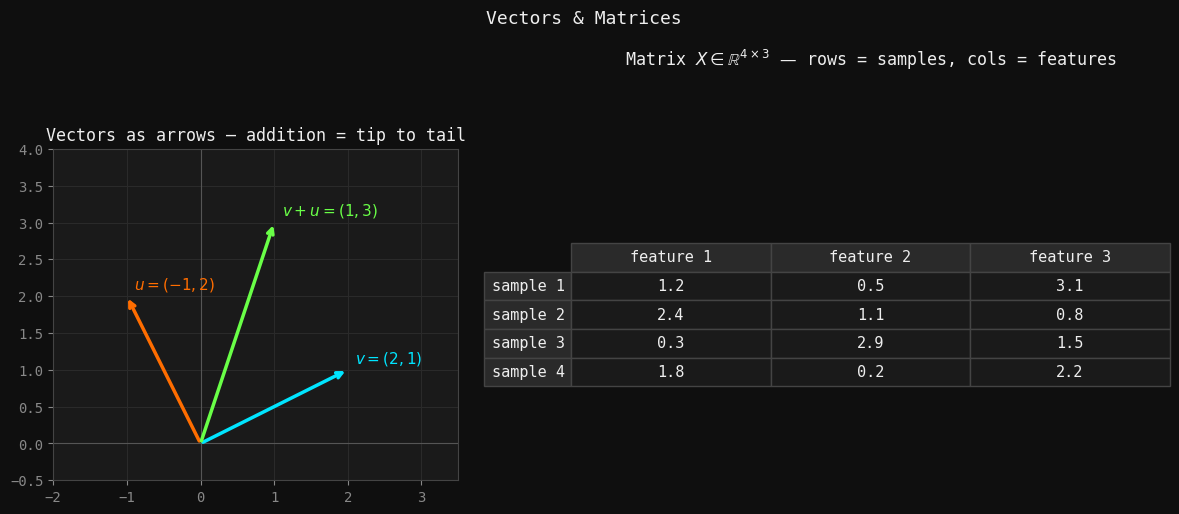

In [2]:
# --- Vectors as arrows in 2D ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Vectors & Matrices', fontsize=13)

# Vectors
ax = axes[0]
vectors = [
    (np.array([2, 1]),   ACCENT,  '$v = (2, 1)$'),
    (np.array([-1, 2]),  ORANGE,  '$u = (-1, 2)$'),
    (np.array([1, 3]),   GREEN,   '$v + u = (1, 3)$'),
]
for vec, color, label in vectors:
    ax.annotate('', xy=vec, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(vec[0]+0.1, vec[1]+0.1, label, color=color, fontsize=11)
ax.set_xlim(-2, 3.5); ax.set_ylim(-0.5, 4)
ax.axhline(0, color='#555', lw=0.8); ax.axvline(0, color='#555', lw=0.8)
ax.set_title('Vectors as arrows — addition = tip to tail')
ax.set_aspect('equal'); ax.grid(True)

# Matrix as data table
ax = axes[1]
ax.axis('off')
data = np.array([[1.2, 0.5, 3.1],
                 [2.4, 1.1, 0.8],
                 [0.3, 2.9, 1.5],
                 [1.8, 0.2, 2.2]])
col_labels = ['feature 1', 'feature 2', 'feature 3']
row_labels = ['sample 1', 'sample 2', 'sample 3', 'sample 4']
table = ax.table(
    cellText=data,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#1a1a1a' if r > 0 and c >= 0 else '#2a2a2a')
    cell.set_edgecolor('#444')
    cell.set_text_props(color='#eee')
ax.set_title('Matrix $X \\in \\mathbb{R}^{4 \\times 3}$ — rows = samples, cols = features',
             pad=60)

plt.tight_layout()
plt.savefig('img/g01_vectors_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Matrix Multiplication

For $A \in \mathbb{R}^{m \times k}$ and $B \in \mathbb{R}^{k \times n}$, the product $C = AB \in \mathbb{R}^{m \times n}$ is:

$$C_{ij} = \sum_{l=1}^{k} A_{il} \cdot B_{lj}$$

Each entry $C_{ij}$ is the **dot product** of row $i$ of $A$ with column $j$ of $B$.

**The inner dimensions must match**: $(m \times k) \cdot (k \times n) = (m \times n)$.

In ML this is everywhere: $\hat{y} = X\theta$ is a matrix-vector product computing all $n$ predictions at once.

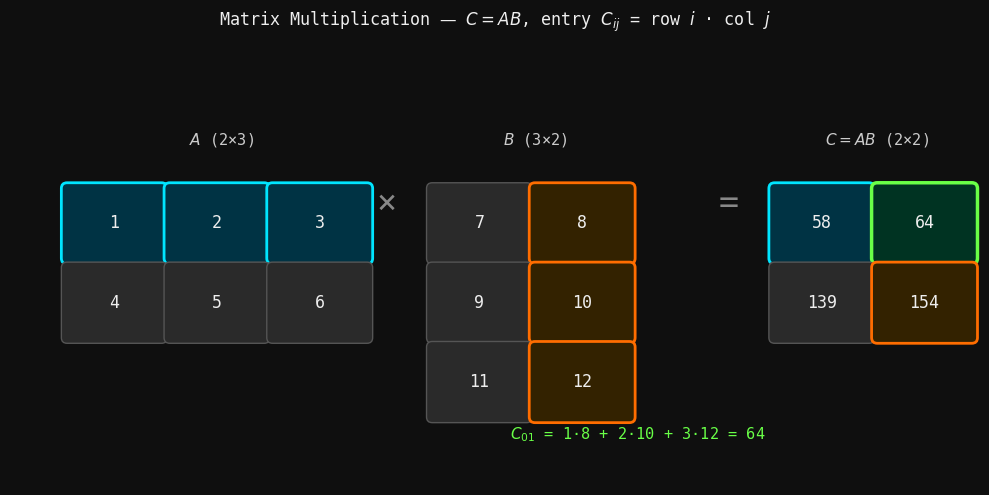

In [3]:
# --- Matrix multiplication diagram ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
fig.suptitle('Matrix Multiplication — $C = AB$, entry $C_{ij}$ = row $i$ · col $j$', fontsize=12)

A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[7, 8], [9, 10], [11, 12]])
C = A @ B

def draw_matrix(ax, M, origin, title, highlight_row=None, highlight_col=None,
                row_color=ACCENT, col_color=ORANGE, result_color=GREEN):
    ox, oy = origin
    rows, cols = M.shape
    cell_w, cell_h = 0.9, 0.7
    ax.text(ox + cols*cell_w/2, oy + rows*cell_h + 0.3, title,
            ha='center', color='#ccc', fontsize=11)
    for i in range(rows):
        for j in range(cols):
            x = ox + j * cell_w
            y = oy + (rows - 1 - i) * cell_h
            fc = '#2a2a2a'
            ec = '#555'
            lw = 1
            if highlight_row is not None and i == highlight_row:
                fc = '#003344'; ec = row_color; lw = 2
            if highlight_col is not None and j == highlight_col:
                fc = '#332200'; ec = col_color; lw = 2
            if highlight_row is not None and highlight_col is not None \
               and i == highlight_row and j == highlight_col:
                fc = '#003322'; ec = result_color; lw = 2.5
            rect = mpatches.FancyBboxPatch((x, y), cell_w*0.92, cell_h*0.88,
                                           boxstyle='round,pad=0.05',
                                           facecolor=fc, edgecolor=ec, lw=lw)
            ax.add_patch(rect)
            ax.text(x + cell_w*0.46, y + cell_h*0.44, str(M[i, j]),
                    ha='center', va='center', color='#eee', fontsize=12)

draw_matrix(ax, A, (0, 1),   '$A$ (2×3)', highlight_row=0)
draw_matrix(ax, B, (3.2, 0.3), '$B$ (3×2)', highlight_col=1)
draw_matrix(ax, C, (6.2, 1),  '$C = AB$ (2×2)', highlight_row=0, highlight_col=1)

ax.text(2.8, 2.1, '×', fontsize=24, color='#888', ha='center')
ax.text(5.8, 2.1, '=', fontsize=24, color='#888', ha='center')

# Annotation for highlighted entry
ax.text(5.0, 0.1,
        f'$C_{{01}}$ = {A[0,0]}·{B[0,1]} + {A[0,1]}·{B[1,1]} + {A[0,2]}·{B[2,1]} = {C[0,1]}',
        color=GREEN, fontsize=11, ha='center')

ax.set_xlim(-0.5, 8); ax.set_ylim(-0.3, 3.5)
plt.tight_layout()
plt.savefig('img/g02_matmul.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Transpose & Inverse

**Transpose** $A^\top$: flip rows and columns. $(A^\top)_{ij} = A_{ji}$.

$$A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \\ 5 & 6 \end{pmatrix} \implies A^\top = \begin{pmatrix} 1 & 3 & 5 \\ 2 & 4 & 6 \end{pmatrix}$$

Key identity: $(AB)^\top = B^\top A^\top$. Used everywhere in gradient derivations.

**Inverse** $A^{-1}$: only exists for square, non-singular matrices. Defined by:

$$A A^{-1} = A^{-1} A = I$$

In ML: the Normal Equation $\hat{\theta} = (X^\top X)^{-1} X^\top y$ requires inverting $X^\top X \in \mathbb{R}^{p \times p}$.  
If $X^\top X$ is singular (collinear features), the inverse does not exist — Ridge regression fixes this by computing $(X^\top X + \lambda I)^{-1}$.

### 1.4 Dot Product

The dot product of two vectors $u, v \in \mathbb{R}^n$:

$$u \cdot v = \sum_{i=1}^n u_i v_i = \|u\| \|v\| \cos\theta$$

where $\theta$ is the angle between them. This gives us two useful readings:
- **Algebraic**: a weighted sum
- **Geometric**: a measure of alignment — how much $v$ points in the direction of $u$

| $u \cdot v$ | Meaning |
|---|---|
| $> 0$ | Vectors point in the same general direction |
| $= 0$ | Vectors are **orthogonal** (perpendicular) |
| $< 0$ | Vectors point in opposite directions |

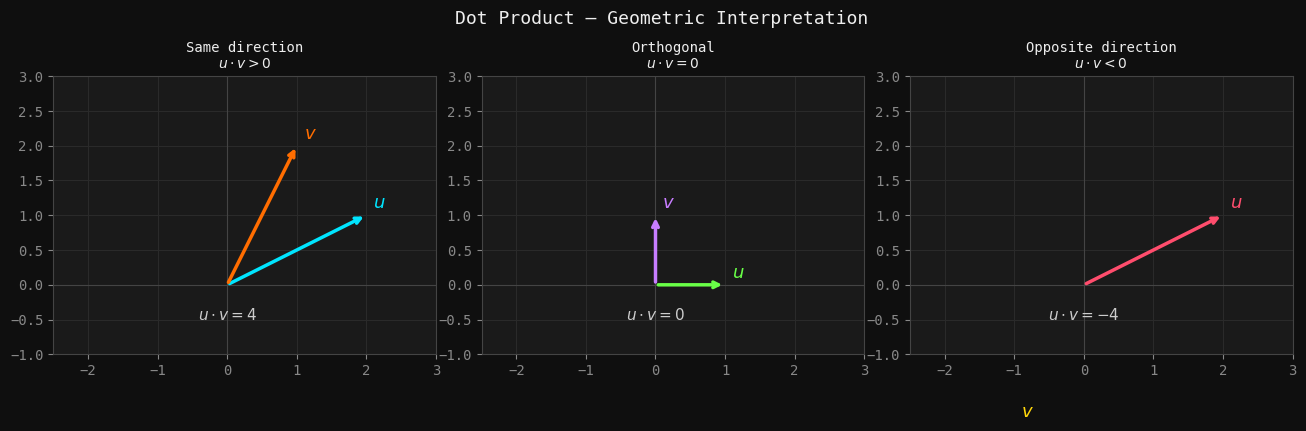

In [4]:
# --- Dot product as geometric projection ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Dot Product — Geometric Interpretation', fontsize=13)

cases = [
    (np.array([2, 1]), np.array([1, 2]),  ACCENT, ORANGE, 'Same direction\n$u \\cdot v > 0$'),
    (np.array([1, 0]), np.array([0, 1]),  GREEN,  PURPLE, 'Orthogonal\n$u \\cdot v = 0$'),
    (np.array([2, 1]), np.array([-1,-2]), RED,    YELLOW, 'Opposite direction\n$u \\cdot v < 0$'),
]

for ax, (u, v, cu, cv, title) in zip(axes, cases):
    ax.annotate('', xy=u, xytext=[0,0], arrowprops=dict(arrowstyle='->', color=cu, lw=2.5))
    ax.annotate('', xy=v, xytext=[0,0], arrowprops=dict(arrowstyle='->', color=cv, lw=2.5))
    ax.text(u[0]+0.1, u[1]+0.1, '$u$', color=cu, fontsize=13)
    ax.text(v[0]+0.1, v[1]+0.1, '$v$', color=cv, fontsize=13)
    dot = np.dot(u, v)
    ax.text(0, -0.5, f'$u \\cdot v = {dot}$', color='#ccc', fontsize=11, ha='center')
    ax.set_xlim(-2.5, 3); ax.set_ylim(-1, 3)
    ax.axhline(0, color='#444', lw=0.8); ax.axvline(0, color='#444', lw=0.8)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10); ax.grid(True)

plt.tight_layout()
plt.savefig('img/g03_dot_product.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.5 Eigenvalues & Eigenvectors

For a square matrix $A$, a vector $v \neq 0$ is an **eigenvector** if multiplying by $A$ only **scales** it — it does not rotate it:

$$A v = \lambda v$$

$\lambda$ is the corresponding **eigenvalue** — the scaling factor.

**Why it matters in ML**:
- **PCA**: the principal components are the eigenvectors of the covariance matrix $\Sigma$. The eigenvalues tell you how much variance each component captures.
- **Convexity check**: a matrix is positive semi-definite (and therefore the loss convex) iff all eigenvalues $\geq 0$.
- **SVD**: generalizes eigendecomposition to non-square matrices — the backbone of dimensionality reduction.

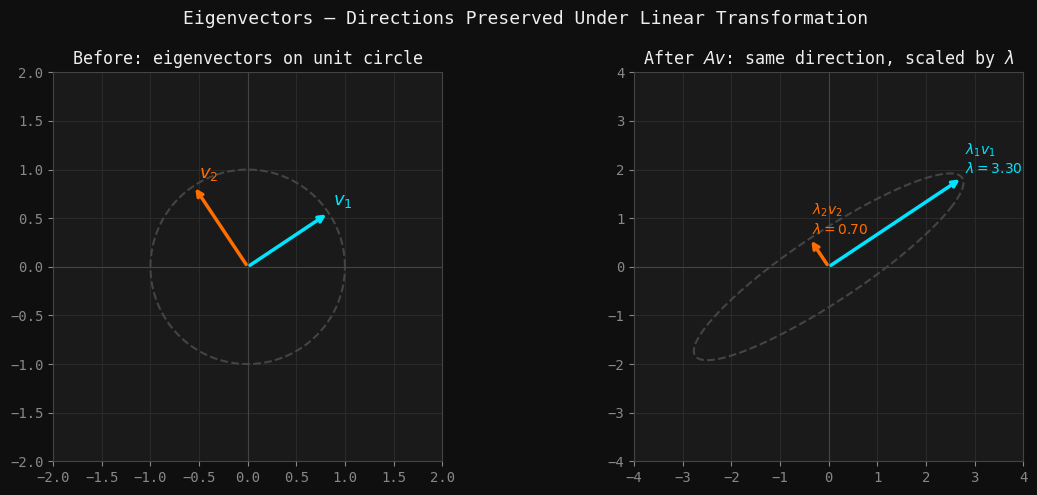

In [5]:
# --- Eigenvectors: directions unchanged by the transformation ---
A = np.array([[2.5, 1.2],
              [1.2, 1.5]])
eigenvalues, eigenvectors = np.linalg.eig(A)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Eigenvectors — Directions Preserved Under Linear Transformation', fontsize=13)

# Before transformation: unit circle + random vectors
ax = axes[0]
theta_arr = np.linspace(0, 2*np.pi, 300)
circle = np.array([np.cos(theta_arr), np.sin(theta_arr)])
ax.plot(*circle, color='#444', lw=1.5, linestyle='--', label='unit circle')

# Eigenvectors before
for i, (ev, color) in enumerate(zip(eigenvectors.T, [ACCENT, ORANGE])):
    ax.annotate('', xy=ev, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(ev[0]+0.05, ev[1]+0.08, f'$v_{i+1}$', color=color, fontsize=13)

ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.axhline(0, color='#444', lw=0.8); ax.axvline(0, color='#444', lw=0.8)
ax.set_title('Before: eigenvectors on unit circle'); ax.grid(True)

# After transformation: ellipse + scaled eigenvectors
ax = axes[1]
ellipse = A @ circle
ax.plot(*ellipse, color='#444', lw=1.5, linestyle='--', label='transformed circle')

for i, (ev, lam, color) in enumerate(zip(eigenvectors.T, eigenvalues, [ACCENT, ORANGE])):
    scaled = lam * ev
    ax.annotate('', xy=scaled, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(scaled[0]+0.05, scaled[1]+0.1,
            f'$\\lambda_{i+1} v_{i+1}$\n$\\lambda={lam:.2f}$', color=color, fontsize=10)

ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.axhline(0, color='#444', lw=0.8); ax.axvline(0, color='#444', lw=0.8)
ax.set_title('After $Av$: same direction, scaled by $\\lambda$'); ax.grid(True)

plt.tight_layout()
plt.savefig('img/g04_eigenvectors.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Calculus

### 2.1 Derivatives

The derivative $f'(x)$ measures the **instantaneous rate of change** of $f$ at $x$ — the slope of the tangent line:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Geometrically: zoom in on $f$ at the point $x$ until it looks like a straight line — the slope of that line is $f'(x)$.

Common derivatives used in ML:

| $f(x)$ | $f'(x)$ |
|--------|--------|
| $x^n$ | $n x^{n-1}$ |
| $e^x$ | $e^x$ |
| $\ln x$ | $\frac{1}{x}$ |
| $\sigma(x) = \frac{1}{1+e^{-x}}$ | $\sigma(x)(1-\sigma(x))$ |

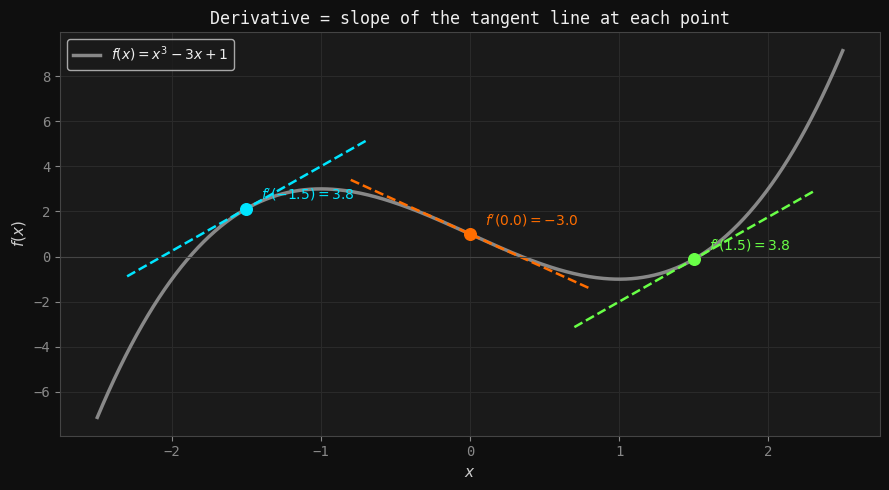

In [6]:
# --- Derivative as slope of tangent line ---
def f(x): return x**3 - 3*x + 1
def df(x): return 3*x**2 - 3

x_range = np.linspace(-2.5, 2.5, 400)
tangent_points = [-1.5, 0.0, 1.5]
colors_t = [ACCENT, ORANGE, GREEN]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_range, f(x_range), color='#888', lw=2.5, label='$f(x) = x^3 - 3x + 1$')

for x0, color in zip(tangent_points, colors_t):
    slope = df(x0)
    y0 = f(x0)
    x_tan = np.linspace(x0 - 0.8, x0 + 0.8, 50)
    y_tan = y0 + slope * (x_tan - x0)
    ax.plot(x_tan, y_tan, color=color, lw=1.8, linestyle='--')
    ax.scatter(x0, y0, color=color, s=70, zorder=5)
    ax.text(x0 + 0.1, y0 + 0.4, f"$f'({x0}) = {slope:.1f}$", color=color, fontsize=10)

ax.axhline(0, color='#444', lw=0.8)
ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
ax.set_title('Derivative = slope of the tangent line at each point')
ax.legend(fontsize=10); ax.grid(True)
plt.tight_layout()
plt.savefig('img/g05_derivative.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Partial Derivatives

When $f$ depends on multiple variables, the **partial derivative** $\frac{\partial f}{\partial x_i}$ measures the rate of change along one variable while **all others are held fixed**.

$$f(x, y) = x^2 + xy + y^2 \implies \frac{\partial f}{\partial x} = 2x + y, \quad \frac{\partial f}{\partial y} = x + 2y$$

Geometrically: slice the 3D surface with a plane parallel to one axis — the partial derivative is the slope of that slice.

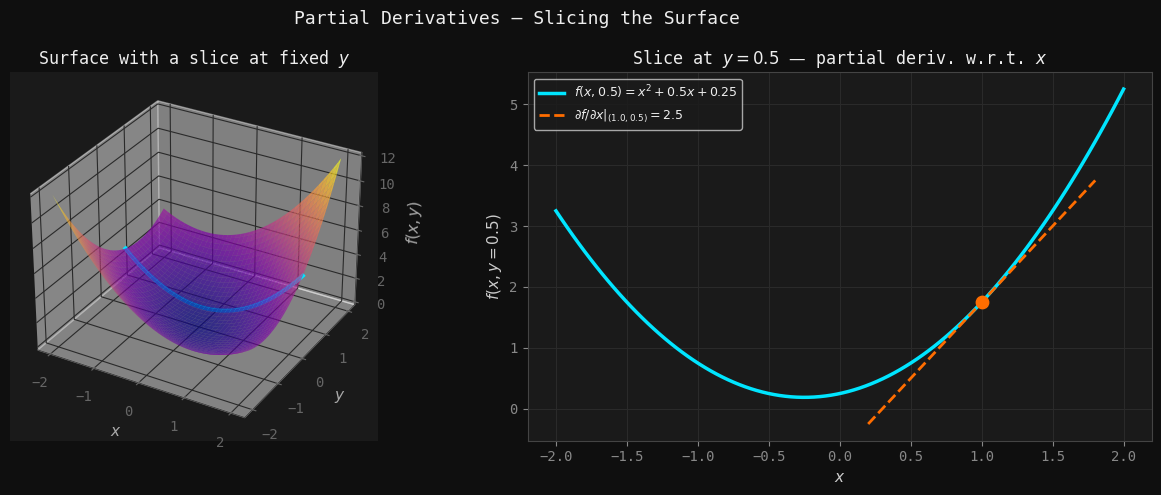

In [7]:
# --- Partial derivatives: slicing a 3D surface ---
def g(x, y): return x**2 + x*y + y**2

xi = np.linspace(-2, 2, 80)
yi = np.linspace(-2, 2, 80)
X2, Y2 = np.meshgrid(xi, yi)
Z2 = g(X2, Y2)

fig = plt.figure(figsize=(13, 5))
fig.suptitle('Partial Derivatives — Slicing the Surface', fontsize=13)

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#1a1a1a')
ax1.plot_surface(X2, Y2, Z2, cmap='plasma', alpha=0.7, linewidth=0)

# Slice at y=0.5
y_fix = 0.5
x_slice = np.linspace(-2, 2, 100)
z_slice = g(x_slice, y_fix)
ax1.plot(x_slice, np.full_like(x_slice, y_fix), z_slice, color=ACCENT, lw=3,
         label=f'slice $y={y_fix}$')
ax1.set_xlabel('$x$', color='#aaa'); ax1.set_ylabel('$y$', color='#aaa')
ax1.set_zlabel('$f(x,y)$', color='#aaa')
ax1.set_title('Surface with a slice at fixed $y$', color='#eee')
ax1.tick_params(colors='#666')

# 2D slice + tangent
ax2 = fig.add_subplot(122)
ax2.plot(x_slice, z_slice, color=ACCENT, lw=2.5,
         label=f'$f(x, {y_fix}) = x^2 + {y_fix}x + {y_fix**2}$')

x0 = 1.0
slope_partial = 2*x0 + y_fix  # df/dx at (x0, y_fix)
z0 = g(x0, y_fix)
x_tan = np.linspace(x0 - 0.8, x0 + 0.8, 50)
z_tan = z0 + slope_partial * (x_tan - x0)
ax2.plot(x_tan, z_tan, color=ORANGE, lw=2, linestyle='--',
         label=f'$\\partial f/\\partial x|_{{({x0},{y_fix})}} = {slope_partial:.1f}$')
ax2.scatter(x0, z0, color=ORANGE, s=80, zorder=5)
ax2.set_xlabel('$x$'); ax2.set_ylabel('$f(x, y=0.5)$')
ax2.set_title('Slice at $y = 0.5$ — partial deriv. w.r.t. $x$')
ax2.legend(fontsize=9); ax2.grid(True)

plt.tight_layout()
plt.savefig('img/g06_partial_derivatives.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 The Chain Rule

If $f = f(g(x))$, the derivative of the composition is:

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

Read it as: *outer derivative times inner derivative*.

**In ML this is everything** — backpropagation is literally just the chain rule applied repeatedly through the layers of a network:

$$\frac{\partial \mathcal{L}}{\partial \theta_1} = \frac{\partial \mathcal{L}}{\partial z_L} \cdot \frac{\partial z_L}{\partial z_{L-1}} \cdot \ldots \cdot \frac{\partial z_2}{\partial z_1} \cdot \frac{\partial z_1}{\partial \theta_1}$$

Each $\frac{\partial z_{k+1}}{\partial z_k}$ is the local gradient at layer $k$. They all multiply together — which is why deep networks suffer from **vanishing or exploding gradients**.

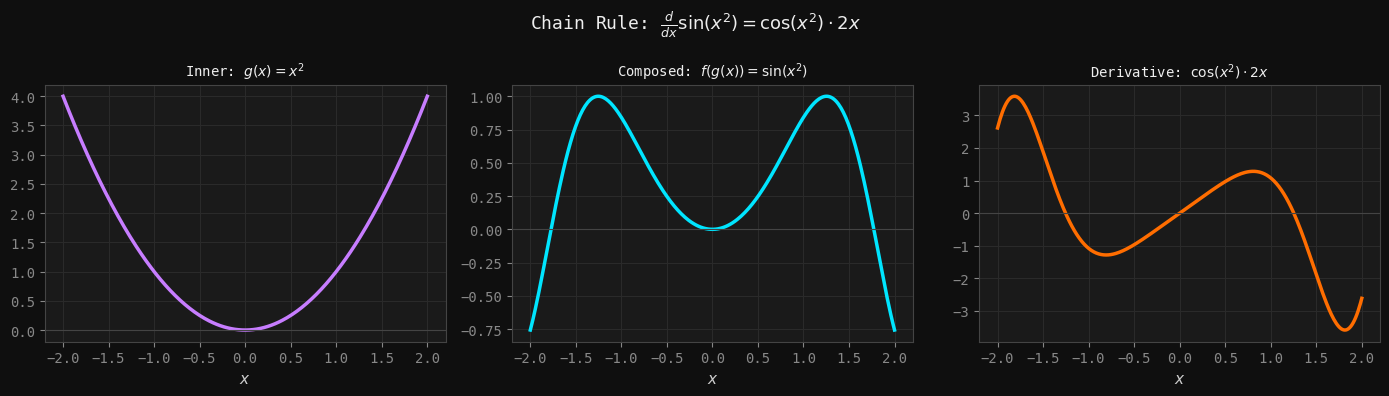

In [8]:
# --- Chain rule: composite function decomposition ---
x_r = np.linspace(-2, 2, 300)
g_x = x_r**2          # inner: g(x) = x^2
f_gx = np.sin(g_x)    # outer: f(g) = sin(g)
# Chain rule: d/dx sin(x^2) = cos(x^2) * 2x
chain = np.cos(g_x) * 2*x_r

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Chain Rule: $\\frac{d}{dx}\\sin(x^2) = \\cos(x^2) \\cdot 2x$', fontsize=13)

for ax, y_data, color, title in [
    (axes[0], g_x,    PURPLE, 'Inner: $g(x) = x^2$'),
    (axes[1], f_gx,   ACCENT, 'Composed: $f(g(x)) = \\sin(x^2)$'),
    (axes[2], chain,  ORANGE, "Derivative: $\\cos(x^2) \\cdot 2x$"),
]:
    ax.plot(x_r, y_data, color=color, lw=2.5)
    ax.axhline(0, color='#444', lw=0.8)
    ax.set_xlabel('$x$'); ax.set_title(title, fontsize=10)
    ax.grid(True)

plt.tight_layout()
plt.savefig('img/g07_chain_rule.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Gradients

The **gradient** $\nabla f$ generalizes the derivative to functions of multiple variables. It stacks all partial derivatives into a vector:

$$\nabla f(x) = \begin{pmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{pmatrix}$$

Key properties:
- $\nabla f$ points in the direction of **steepest ascent**
- $-\nabla f$ points in the direction of **steepest descent** → used in gradient descent
- $\|\nabla f\|$ tells you how steep the surface is at that point
- At a minimum (or maximum): $\nabla f = 0$

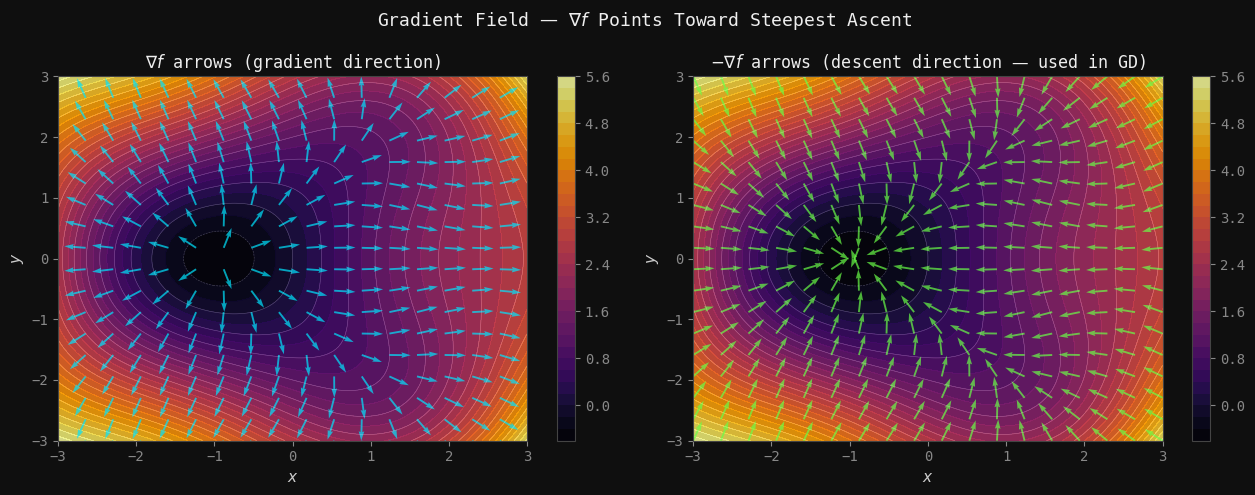

In [9]:
# --- Gradient field on a 2D surface ---
def h(x, y): return np.sin(x) * np.cos(y) + 0.3*(x**2 + y**2)
def dh_dx(x, y): return np.cos(x) * np.cos(y) + 0.6*x
def dh_dy(x, y): return -np.sin(x) * np.sin(y) + 0.6*y

xi = np.linspace(-3, 3, 200)
yi = np.linspace(-3, 3, 200)
X3, Y3 = np.meshgrid(xi, yi)
Z3 = h(X3, Y3)

# Coarser grid for arrows
xq = np.linspace(-3, 3, 18)
yq = np.linspace(-3, 3, 18)
Xq, Yq = np.meshgrid(xq, yq)
Gx = dh_dx(Xq, Yq)
Gy = dh_dy(Xq, Yq)
# Normalise for display
norm_G = np.sqrt(Gx**2 + Gy**2) + 1e-8

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gradient Field — $\\nabla f$ Points Toward Steepest Ascent', fontsize=13)

# Contour + gradient arrows
ax = axes[0]
cp = ax.contourf(X3, Y3, Z3, levels=30, cmap='inferno', alpha=0.85)
ax.contour(X3, Y3, Z3, levels=15, colors='white', linewidths=0.4, alpha=0.3)
ax.quiver(Xq, Yq, Gx/norm_G, Gy/norm_G,
          color=ACCENT, alpha=0.7, scale=22, width=0.004)
ax.set_title('$\\nabla f$ arrows (gradient direction)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(cp, ax=ax)

# Negative gradient = descent direction
ax = axes[1]
cp2 = ax.contourf(X3, Y3, Z3, levels=30, cmap='inferno', alpha=0.85)
ax.contour(X3, Y3, Z3, levels=15, colors='white', linewidths=0.4, alpha=0.3)
ax.quiver(Xq, Yq, -Gx/norm_G, -Gy/norm_G,
          color=GREEN, alpha=0.7, scale=22, width=0.004)
ax.set_title('$-\\nabla f$ arrows (descent direction — used in GD)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.colorbar(cp2, ax=ax)

plt.tight_layout()
plt.savefig('img/g08_gradient_field.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Probability & Statistics

### 3.1 Random Variables, Expectation & Variance

A **random variable** $X$ is a quantity whose value is determined by a random process.

**Expectation** $\mathbb{E}[X]$ — the average value over many repetitions:

$$\mathbb{E}[X] = \sum_x x \, p(x) \quad \text{(discrete)}, \qquad \mathbb{E}[X] = \int x \, p(x)\, dx \quad \text{(continuous)}$$

**Variance** $\text{Var}(X)$ — how spread out the values are around the mean:

$$\text{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

**Standard deviation** $\sigma = \sqrt{\text{Var}(X)}$ — same unit as $X$, easier to interpret.

### 3.2 Common Distributions

**Gaussian (Normal)** $X \sim \mathcal{N}(\mu, \sigma^2)$

$$p(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

The most important distribution in ML: noise in linear regression, weight initialization in NNs, and the Central Limit Theorem makes it appear everywhere.

**Bernoulli** $X \sim \text{Bern}(p)$ — a single coin flip: $P(X=1) = p$, $P(X=0) = 1-p$.  
This is the output model behind logistic regression.

**Binomial** $X \sim \text{Bin}(n, p)$ — number of successes in $n$ independent Bernoulli trials:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

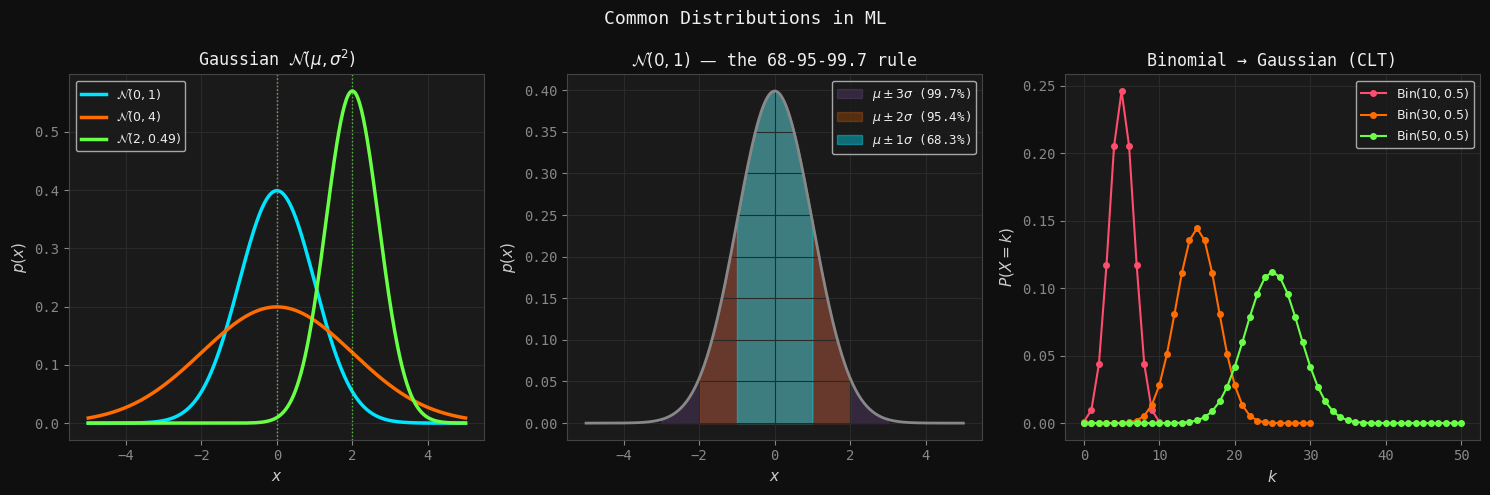

In [10]:
# --- Gaussian family + Bernoulli/Binomial ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Common Distributions in ML', fontsize=13)

x_g = np.linspace(-5, 5, 400)

# Gaussians with different params
ax = axes[0]
configs = [(0, 1, ACCENT, '$\\mathcal{N}(0,1)$'),
           (0, 2, ORANGE, '$\\mathcal{N}(0,4)$'),
           (2, 0.7, GREEN, '$\\mathcal{N}(2, 0.49)$')]
for mu, sigma, color, label in configs:
    ax.plot(x_g, norm.pdf(x_g, mu, sigma), color=color, lw=2.5, label=label)
    ax.axvline(mu, color=color, lw=1, linestyle=':', alpha=0.7)
ax.set_title('Gaussian $\\mathcal{N}(\\mu, \\sigma^2)$')
ax.set_xlabel('$x$'); ax.set_ylabel('$p(x)$')
ax.legend(fontsize=9); ax.grid(True)

# Effect of sigma: shade 1/2/3 sigma regions
ax = axes[1]
mu0, sig0 = 0, 1
ax.plot(x_g, norm.pdf(x_g, mu0, sig0), color='#888', lw=2)
for nsig, alpha, color, label in [
    (3, 0.15, PURPLE, '$\\mu \\pm 3\\sigma$ (99.7%)'),
    (2, 0.25, ORANGE, '$\\mu \\pm 2\\sigma$ (95.4%)'),
    (1, 0.40, ACCENT, '$\\mu \\pm 1\\sigma$ (68.3%)'),
]:
    x_fill = np.linspace(mu0 - nsig*sig0, mu0 + nsig*sig0, 300)
    ax.fill_between(x_fill, norm.pdf(x_fill, mu0, sig0), alpha=alpha, color=color, label=label)
ax.set_title('$\\mathcal{N}(0,1)$ — the 68-95-99.7 rule')
ax.set_xlabel('$x$'); ax.set_ylabel('$p(x)$')
ax.legend(fontsize=9); ax.grid(True)

# Binomial converging to Gaussian
ax = axes[2]
k_vals = np.arange(0, 51)
for n, color, label in [(10, RED, '$\\text{Bin}(10, 0.5)$'),
                         (30, ORANGE, '$\\text{Bin}(30, 0.5)$'),
                         (50, GREEN, '$\\text{Bin}(50, 0.5)$')]:
    probs = binom.pmf(k_vals[:n+1], n, 0.5)
    ax.plot(k_vals[:n+1], probs, 'o-', color=color, lw=1.5, ms=4, label=label)
ax.set_title('Binomial → Gaussian (CLT)')
ax.set_xlabel('$k$'); ax.set_ylabel('$P(X=k)$')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/g09_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Covariance & Correlation

**Covariance** between two variables $X$ and $Y$:

$$\text{Cov}(X, Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])]$$

- $\text{Cov} > 0$: $X$ and $Y$ tend to move together
- $\text{Cov} < 0$: they move in opposite directions
- $\text{Cov} = 0$: no linear relationship

**Pearson Correlation** — normalised covariance, always in $[-1, 1]$:

$$\rho_{XY} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}$$

**Covariance matrix** $\Sigma$ for a $p$-dimensional vector: $\Sigma_{ij} = \text{Cov}(X_i, X_j)$.  
Its eigenvectors are the **principal components** (PCA), its eigenvalues the variance explained.

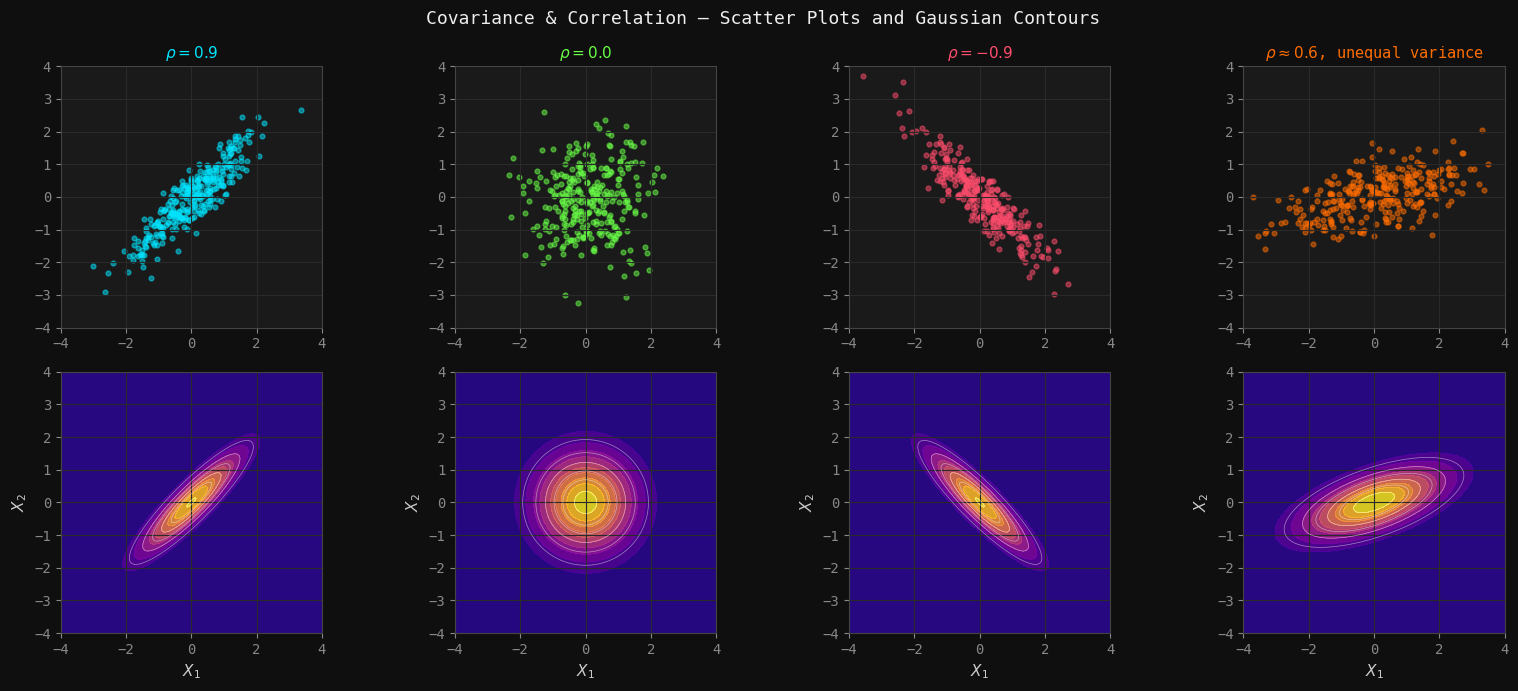

In [11]:
# --- Covariance: 4 scatter cases + 2D Gaussian contours ---
np.random.seed(7)
n_pts = 300

cases_cov = [
    (np.array([[1, 0.9],[0.9, 1]]),  ACCENT, '$\\rho = 0.9$'),
    (np.array([[1, 0.0],[0.0, 1]]),  GREEN,  '$\\rho = 0.0$'),
    (np.array([[1,-0.9],[-0.9,1]]),  RED,    '$\\rho = -0.9$'),
    (np.array([[2, 0.6],[0.6, 0.5]]), ORANGE,'$\\rho \\approx 0.6$, unequal variance'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Covariance & Correlation — Scatter Plots and Gaussian Contours', fontsize=13)

xi2 = np.linspace(-4, 4, 100)
yi2 = np.linspace(-4, 4, 100)
X4, Y4 = np.meshgrid(xi2, yi2)
pos = np.dstack((X4, Y4))

for i, (cov_mat, color, label) in enumerate(cases_cov):
    data = np.random.multivariate_normal([0, 0], cov_mat, n_pts)
    rho = cov_mat[0,1] / np.sqrt(cov_mat[0,0]*cov_mat[1,1])

    # Scatter
    ax_sc = axes[0][i]
    ax_sc.scatter(data[:,0], data[:,1], color=color, s=12, alpha=0.5)
    ax_sc.set_title(label, color=color, fontsize=11)
    ax_sc.set_xlim(-4,4); ax_sc.set_ylim(-4,4)
    ax_sc.set_aspect('equal'); ax_sc.grid(True)

    # Contour
    ax_ct = axes[1][i]
    rv = multivariate_normal([0, 0], cov_mat)
    Z_cov = rv.pdf(pos)
    ax_ct.contourf(X4, Y4, Z_cov, levels=10, cmap='plasma', alpha=0.85)
    ax_ct.contour(X4, Y4, Z_cov, levels=6, colors='white', linewidths=0.5, alpha=0.5)
    ax_ct.set_xlim(-4,4); ax_ct.set_ylim(-4,4)
    ax_ct.set_aspect('equal'); ax_ct.grid(True)
    ax_ct.set_xlabel('$X_1$'); ax_ct.set_ylabel('$X_2$')

plt.tight_layout()
plt.savefig('img/g10_covariance.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Bayes' Theorem

Bayes' theorem tells you how to **update a belief** when you receive new evidence:

$$\underbrace{P(A \mid B)}_{\text{posterior}} = \frac{\overbrace{P(B \mid A)}^{\text{likelihood}} \cdot \overbrace{P(A)}^{\text{prior}}}{\underbrace{P(B)}_{\text{evidence}}}$$

In ML terms, replacing $A$ with model parameters $\theta$ and $B$ with observed data $\mathcal{D}$:

$$P(\theta \mid \mathcal{D}) = \frac{P(\mathcal{D} \mid \theta) \cdot P(\theta)}{P(\mathcal{D})}$$

| Term | Meaning |
|------|--------|
| $P(\theta)$ | Prior — what you believe about $\theta$ before seeing data |
| $P(\mathcal{D} \mid \theta)$ | Likelihood — how probable is the data given $\theta$ |
| $P(\theta \mid \mathcal{D})$ | Posterior — updated belief after seeing the data |
| $P(\mathcal{D})$ | Evidence — normalisation constant (often intractable) |

**MLE** (used in Linear/Logistic Regression) maximises only the likelihood, ignoring the prior.  
**MAP** (used in Ridge Regression) maximises the posterior = likelihood + prior — Ridge's L2 penalty is a Gaussian prior on $\theta$.

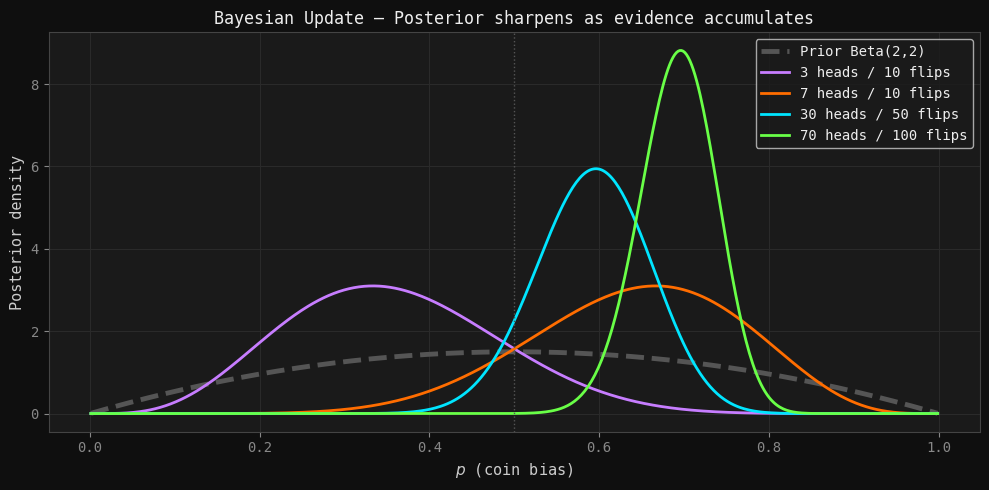

In [15]:
# --- Bayesian update: prior → likelihood → posterior ---
# Estimating the bias p of a coin after observing k heads in n flips
# Prior: Beta(2,2) — weakly centered around 0.5
from scipy.stats import beta as beta_dist

p_vals = np.linspace(0.001, 0.999, 500)
observations = [(0, 0, '#555', 'Prior Beta(2,2)'),
                (3, 10, PURPLE, '3 heads / 10 flips'),
                (7, 10, ORANGE, '7 heads / 10 flips'),
                (30, 50, ACCENT, '30 heads / 50 flips'),
                (70, 100, GREEN, '70 heads / 100 flips')]

fig, ax = plt.subplots(figsize=(10, 5))
prior_a, prior_b = 2, 2

for k, n, color, label in observations:
    post_a = prior_a + k
    post_b = prior_b + (n - k)
    pdf = beta_dist.pdf(p_vals, post_a, post_b)
    lw = 3.5 if n == 0 else 2
    ls = '--' if n == 0 else '-'
    ax.plot(p_vals, pdf, color=color, lw=lw, linestyle=ls, label=label)

ax.axvline(0.5, color='#555', lw=1, linestyle=':')
ax.set_xlabel('$p$ (coin bias)')
ax.set_ylabel('Posterior density')
ax.set_title('Bayesian Update — Posterior sharpens as evidence accumulates')
ax.legend(fontsize=10); ax.grid(True)
plt.tight_layout()
plt.savefig('img/g11_bayes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Convexity & Norms

### 4.1 Convexity

A function $f$ is **convex** if the line segment between any two points on its graph lies *above* the graph:

$$f(\lambda a + (1-\lambda)b) \leq \lambda f(a) + (1-\lambda) f(b), \quad \lambda \in [0,1]$$

**Why it is the most important property in optimisation**:
- Every local minimum is a global minimum
- Gradient descent is guaranteed to converge
- No saddle-point traps

A function is **strictly convex** if the inequality is strict (unique minimum).  
A function is **strongly convex** with parameter $m > 0$ if $f(x) - \frac{m}{2}\|x\|^2$ is convex — this guarantees linear convergence of gradient descent.

**Second-order check**: $f$ is convex iff $f''(x) \geq 0$ for all $x$ (1D), or iff the Hessian $\nabla^2 f \succeq 0$ (multi-D).

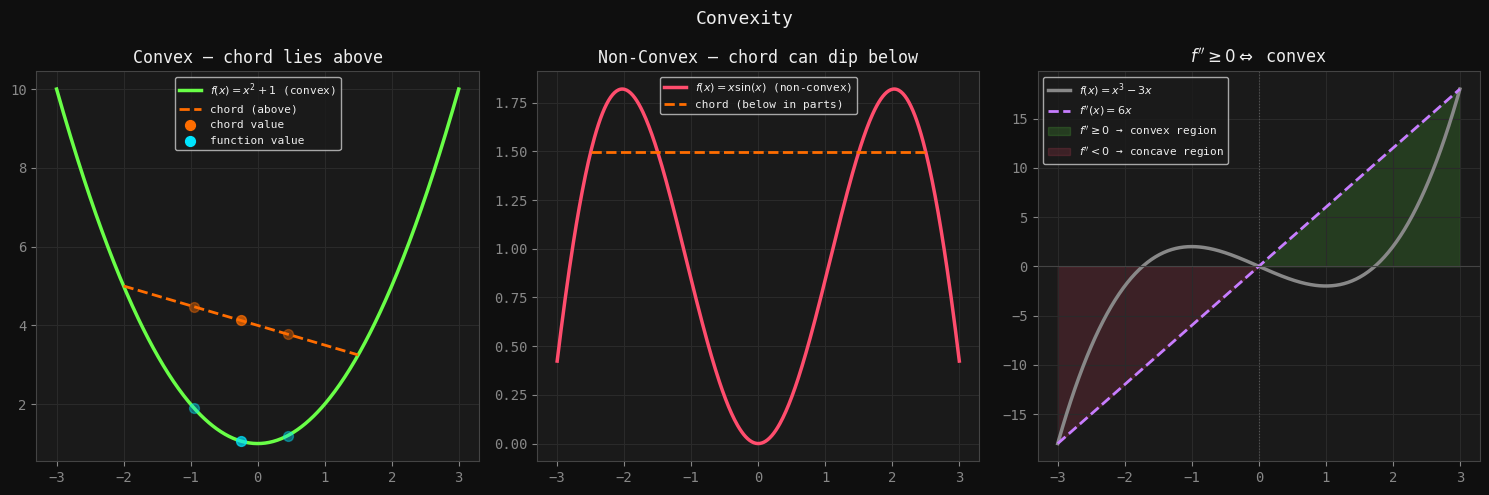

In [16]:
# --- Convex vs non-convex, + second derivative sign ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Convexity', fontsize=13)

x_c = np.linspace(-3, 3, 400)

# Convex: chord always above
ax = axes[0]
f_conv = x_c**2 + 1
ax.plot(x_c, f_conv, color=GREEN, lw=2.5, label='$f(x) = x^2 + 1$ (convex)')
a_pt, b_pt = -2.0, 1.5
for lam, alpha in zip([0.3, 0.5, 0.7], [0.4, 0.7, 0.4]):
    mid_x = lam*a_pt + (1-lam)*b_pt
    chord_y = lam*(a_pt**2+1) + (1-lam)*(b_pt**2+1)
    func_y  = mid_x**2 + 1
    ax.scatter(mid_x, chord_y, color=ORANGE, s=50, zorder=5, alpha=alpha)
    ax.scatter(mid_x, func_y,  color=ACCENT,  s=50, zorder=5, alpha=alpha)
ax.plot([a_pt, b_pt], [a_pt**2+1, b_pt**2+1], color=ORANGE, lw=2,
        linestyle='--', label='chord (above)')
ax.scatter([], [], color=ORANGE, s=50, label='chord value')
ax.scatter([], [], color=ACCENT, s=50, label='function value')
ax.set_title('Convex — chord lies above')
ax.legend(fontsize=8); ax.grid(True)

# Non-convex
ax = axes[1]
f_nonconv = np.sin(x_c) * x_c
ax.plot(x_c, f_nonconv, color=RED, lw=2.5, label='$f(x) = x\\sin(x)$ (non-convex)')
a_pt2, b_pt2 = -2.5, 2.5
ax.plot([a_pt2, b_pt2],
        [np.sin(a_pt2)*a_pt2, np.sin(b_pt2)*b_pt2],
        color=ORANGE, lw=2, linestyle='--', label='chord (below in parts)')
ax.set_title('Non-Convex — chord can dip below')
ax.legend(fontsize=8); ax.grid(True)

# Second derivative sign
ax = axes[2]
f2      = x_c**3 - 3*x_c
f2_dd   = 6*x_c
ax.plot(x_c, f2,    color='#888', lw=2.5, label="$f(x) = x^3 - 3x$")
ax.plot(x_c, f2_dd, color=PURPLE, lw=2,   linestyle='--', label="$f''(x) = 6x$")
ax.axhline(0, color='#444', lw=0.8)
ax.axvline(0, color='#555', lw=0.8, linestyle=':')
ax.fill_between(x_c, 0, f2_dd, where=(f2_dd >= 0), alpha=0.15, color=GREEN,  label="$f'' \\geq 0$ → convex region")
ax.fill_between(x_c, 0, f2_dd, where=(f2_dd <  0), alpha=0.15, color=RED,    label="$f'' < 0$ → concave region")
ax.set_title('$f\'\' \\geq 0 \\Leftrightarrow$ convex')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('img/g12_convexity.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Norms

A **norm** $\|v\|$ is a function that measures the **size** of a vector. Formally it satisfies: non-negativity, scaling, and the triangle inequality.

The general **$L^p$ norm**:

$$\|v\|_p = \left(\sum_{i=1}^n |v_i|^p\right)^{1/p}$$

The three norms you'll see constantly in ML:

| Norm | Formula | Geometry | Used for |
|------|---------|----------|----------|
| **L1** | $\sum_i |v_i|$ | Diamond (taxicab distance) | Lasso, sparse solutions |
| **L2** | $\sqrt{\sum_i v_i^2}$ | Circle / Euclidean distance | Ridge, distances, gradients |
| **L∞** | $\max_i |v_i|$ | Square (max component) | Robustness, minimax problems |

**Why does L1 induce sparsity?** Its unit ball has corners on the axes. When you project an off-axis point onto the L1 ball, it is most likely to land on a corner — where one coordinate is zero.

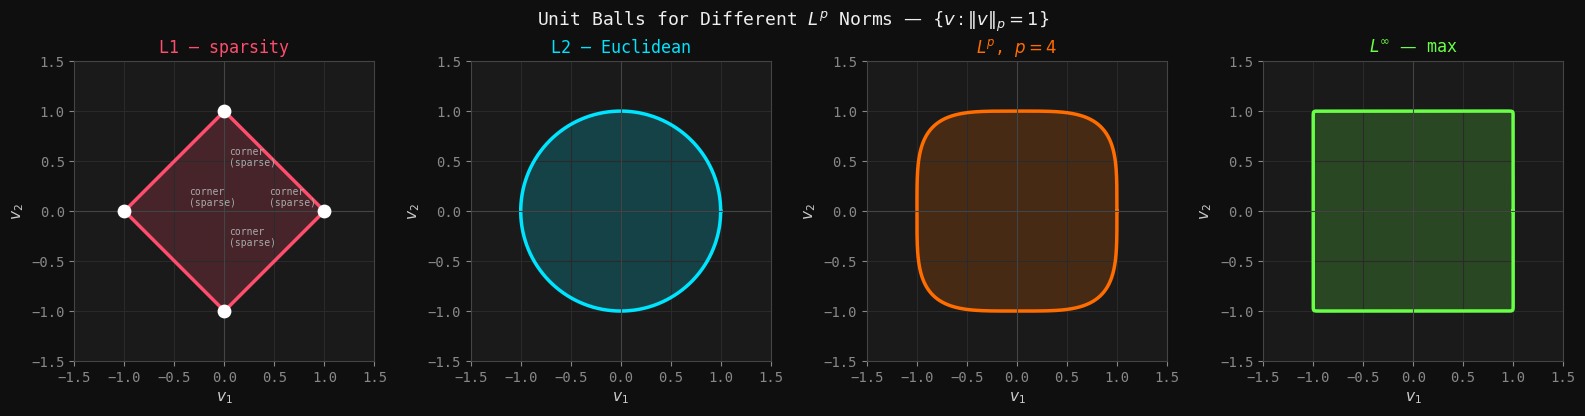

In [17]:
# --- Unit balls for L1, L2, L_inf and Lp intermediate ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Unit Balls for Different $L^p$ Norms — $\\{v : \\|v\\|_p = 1\\}$', fontsize=13)

theta_arr = np.linspace(0, 2*np.pi, 1000)

def lp_unit_ball(p, n_pts=2000):
    """Parametric unit ball boundary for Lp norm in 2D."""
    angles = np.linspace(0, 2*np.pi, n_pts)
    points = []
    for a in angles:
        # Direction vector
        d = np.array([np.cos(a), np.sin(a)])
        # Scale so that ||t*d||_p = 1 -> t = 1/||d||_p
        lp = np.sum(np.abs(d)**p)**(1/p)
        points.append(d / lp)
    return np.array(points)

configs = [
    (1,   RED,    '$L^1$ norm\n(diamond)', 'L1 — sparsity'),
    (2,   ACCENT, '$L^2$ norm\n(circle)',  'L2 — Euclidean'),
    (4,   ORANGE, '$L^4$ norm\n(squircle)','$L^p$, $p=4$'),
    (100, GREEN,  '$L^\\infty$ norm\n(square)', '$L^\\infty$ — max'),
]

for ax, (p, color, label, title) in zip(axes, configs):
    ball = lp_unit_ball(p)
    ax.fill(ball[:,0], ball[:,1], alpha=0.2, color=color)
    ax.plot(ball[:,0], ball[:,1], color=color, lw=2.5)
    ax.axhline(0, color='#444', lw=0.8); ax.axvline(0, color='#444', lw=0.8)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(title, color=color)
    ax.grid(True)
    ax.set_xlabel('$v_1$'); ax.set_ylabel('$v_2$')
    # Mark corners for L1
    if p == 1:
        for pt in [(1,0),(-1,0),(0,1),(0,-1)]:
            ax.scatter(*pt, color='white', s=80, zorder=5)
            ax.annotate('corner\n(sparse)', xy=pt,
                        xytext=(pt[0]*0.4+0.05, pt[1]*0.4+0.05),
                        color='#aaa', fontsize=7)

plt.tight_layout()
plt.savefig('img/g13_norms.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Table

| Concept | Key formula | Where it shows up in ML |
|---------|-------------|------------------------|
| Matrix multiply | $C_{ij} = \sum_l A_{il} B_{lj}$ | Predictions $\hat{y} = X\theta$, layer activations |
| Dot product | $u \cdot v = \|u\|\|v\|\cos\theta$ | Similarity, projections, attention scores |
| Eigenvectors | $Av = \lambda v$ | PCA, covariance structure, convexity check |
| Derivative | $f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}$ | Loss minimisation |
| Chain rule | $(f \circ g)' = f'(g) \cdot g'$ | Backpropagation |
| Gradient | $\nabla f = (\partial f/\partial x_i)_i$ | Gradient descent update rule |
| Gaussian | $\mathcal{N}(\mu, \sigma^2)$ | Noise model, weight init, CLT |
| Covariance | $\text{Cov}(X,Y) = \mathbb{E}[(X-\mu_X)(Y-\mu_Y)]$ | Feature correlation, PCA |
| Bayes | $P(\theta\|\mathcal{D}) \propto P(\mathcal{D}\|\theta)P(\theta)$ | Probabilistic models, MAP = Ridge |
| Convexity | $f(\lambda a + (1-\lambda)b) \leq \lambda f(a) + (1-\lambda)f(b)$ | Guarantees GD finds global min |
| L1 / L2 norm | $\sum|v_i|$ / $\sqrt{\sum v_i^2}$ | Regularisation, distance metrics |

---